In [1]:
# Install necessary libraries
!pip install scikit-learn bayesian-optimization

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt

In [3]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
            'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour', 'vessel_type']
target = 'TravelTime_seconds'

# Handle NaN values for the entire dataset
data[features] = data[features].fillna(data[features].mean())

# Verify that NaN values are handled
print("NaN values in the dataset after handling:", data[features].isnull().sum().sum())

NaN values in the dataset after handling: 0


<ipython-input-3-e859970e0070>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [4]:
# Split data into train and test sets
train_data, test_data = train_test_split(data[features + [target]], test_size=0.2, random_state=42)

# Separate features and target
X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

In [6]:
# Bayesian Optimization for Hyperparameter Tuning
def knn_hyperopt(n_neighbors, weights, p):
    """
    Objective function for Bayesian Optimization.
    """
    # Convert hyperparameters to appropriate types
    n_neighbors = int(n_neighbors)
    p = int(p)

    # Map weights to their corresponding string values
    weights_mapping = {0: 'uniform', 1: 'distance'}
    weights = weights_mapping[int(weights)]

    # Initialize and train the KNN model
    model = KNeighborsRegressor(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p
    )

    # Fit the model
    model.fit(X_train, y_train)

    # Predict on the validation set (using a subset of the training data for faster evaluation)
    y_pred = model.predict(X_test)

    # Use negative MAE as the objective (Bayesian Optimization maximizes the objective)
    return -mean_absolute_error(y_test, y_pred)

# Define the parameter bounds for Bayesian Optimization
param_bounds = {
    'n_neighbors': (1, 50),  # Number of neighbors
    'weights': (0, 1),  # Weight function (0: uniform, 1: distance)
    'p': (1, 2),  # Power parameter for Minkowski distance (1: Manhattan, 2: Euclidean)
}

# Initialize Bayesian Optimization
optimizer = BayesianOptimization(
    f=knn_hyperopt,
    pbounds=param_bounds,
    random_state=42
)

# Perform optimization
optimizer.maximize(init_points=5, n_iter=10)  # Adjust init_points and n_iter as needed

# Print the best hyperparameters
best_params = optimizer.max['params']
print("Best Hyperparameters from Bayesian Optimization:")
print(best_params)

# Map the weights back to their string values
weights_mapping = {0: 'uniform', 1: 'distance'}
best_params['weights'] = weights_mapping[int(best_params['weights'])]
print("Best Hyperparameters with Mapped Weights:")
print(best_params)

|   iter    |  target   | n_neig... |     p     |  weights  |
-------------------------------------------------------------
| 1         | -8.21e+04 | 19.35     | 1.951     | 0.732     |
| 2         | -8.807e+0 | 30.33     | 1.156     | 0.156     |
| 3         | -7.522e+0 | 3.846     | 1.866     | 0.6011    |
| 4         | -9.049e+0 | 35.7      | 1.021     | 0.9699    |
| 5         | -9.269e+0 | 41.79     | 1.212     | 0.1818    |
| 6         | -8.471e+0 | 1.085     | 1.098     | 0.1016    |
| 7         | -7.475e+0 | 5.336     | 1.822     | 0.3786    |
| 8         | -7.824e+0 | 11.13     | 1.999     | 0.9866    |
| 9         | -9.573e+0 | 50.0      | 1.794     | 0.8735    |
| 10        | -7.936e+0 | 15.07     | 1.197     | 0.004776  |
| 11        | -7.604e+0 | 7.91      | 1.009     | 0.948     |
| 12        | -7.395e+0 | 4.808     | 1.035     | 0.9719    |
| 13        | -7.475e+0 | 5.114     | 2.0       | 0.9713    |
| 14        | -8.469e+0 | 24.31     | 1.126     | 0.05107   |
| 15    

In [7]:
# Train the final model with the best hyperparameters
best_model = KNeighborsRegressor(
    n_neighbors=int(best_params['n_neighbors']),
    weights=best_params['weights'],
    p=int(best_params['p'])
)

# Fit the best model
best_model.fit(X_train, y_train)

# Predict on the test set
y_pred_best = best_model.predict(X_test)

In [8]:
# Evaluate the best model
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("\nBest Model Performance:")
print("Mean Absolute Error:", mae_best)
print("Mean Squared Error:", mse_best)
print("R-squared:", r2_best)


Best Model Performance:
Mean Absolute Error: 73953.001265317
Mean Squared Error: 39633709426.98144
R-squared: 0.707335730586585


In [9]:
# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(X, y, kf):
    mae_scores = []
    mse_scores = []
    r2_scores = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train KNN model with best hyperparameters
        model = KNeighborsRegressor(
            n_neighbors=int(best_params['n_neighbors']),
            weights=best_params['weights'],
            p=int(best_params['p'])
        )
        model.fit(X_train, y_train)

        # Predict on the test set
        y_pred = model.predict(X_test)

        # Calculate metrics
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        mse_scores.append(mean_squared_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))

    return mae_scores, mse_scores, r2_scores

# Perform K-Fold Cross-Validation
mae_scores, mse_scores, r2_scores = evaluate_model(data[features], data[target], kf)

# Print results
print(f'MAE Scores: {mae_scores}')
print(f'MSE Scores: {mse_scores}')
print(f'R2 Scores: {r2_scores}')
print(f'Mean MAE: {sum(mae_scores)/len(mae_scores)}')
print(f'Mean MSE: {sum(mse_scores)/len(mse_scores)}')
print(f'Mean R2: {sum(r2_scores)/len(r2_scores)}')

MAE Scores: [73953.001265317, 74745.7457378796, 77981.67121736814, 72525.21244006393, 80122.81581401546]
MSE Scores: [39633709426.98144, 44171316273.74068, 44589236869.97934, 41863055004.98688, 49629845696.729935]
R2 Scores: [0.707335730586585, 0.69301964099776, 0.6953928325010407, 0.6908932828469132, 0.6582686459506297]
Mean MAE: 75865.68929492883
Mean MSE: 43977432654.48366
Mean R2: 0.6889820265765858


In [10]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for the best model
knn_mape = mean_absolute_percentage_error(y_test, y_pred_best)
print(f"KNN MAPE: {knn_mape:.2f}%")

KNN MAPE: 14.67%


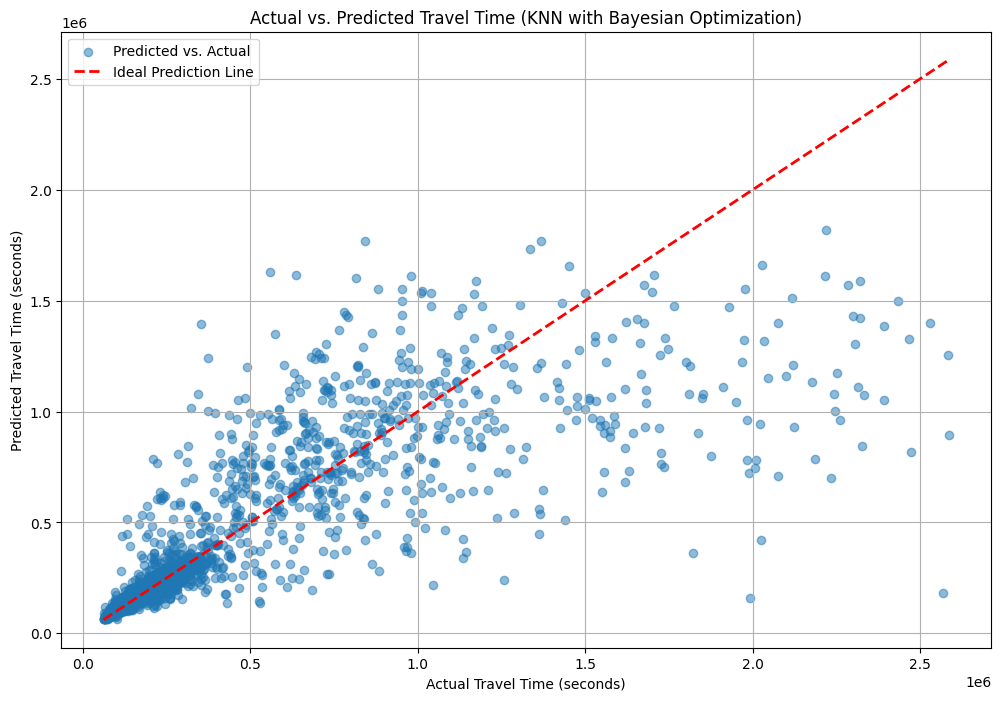

In [12]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred_best, alpha=0.5, label='Predicted vs. Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2, label='Ideal Prediction Line')
plt.title('Actual vs. Predicted Travel Time (KNN with Bayesian Optimization)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.legend()
plt.show()